# Exercício 11 — Passeio aleatório simples

**Enunciado:** Sejam $Y_1, Y_2, \dots, Y_n$ variáveis aleatórias independentes tais que

$$\mathbb{P}(Y_i = 1) = \mathbb{P}(Y_i = -1) = \frac{1}{2},$$

e defina

$$X_n = \sum_{i=1}^{n} Y_i.$$

Interprete $Y_i = 1$ como uma alta de R\$1 no preço de uma ação no dia $i$, $Y_i = -1$ como uma queda de
R\$1, e $X_n$ como a variação acumulada do preço em relação ao seu valor inicial após $n$ dias.

- (a) Gere e represente graficamente uma realização de $X_n$ para $n = 1, \dots, 1000$. Repita algumas vezes e descreva qualitativamente o comportamento observado.
- (b) Calcule $E[X_n]$ e $Var(X_n)$. O fato de $E[X_n] = 0$ significa que $X_n$ deve permanecer próximo de zero quando $n$ é grande? Explique.
- (c) Seja $K_n$ o número de dias de alta entre os primeiros $n$ dias. Mostre que $X_n = 2K_n - n$ e determine a distribuição de $K_n$. A partir desse resultado, obtenha uma expressão para $\mathbb{P}(X_n = x)$.
- (d) Repita a simulação muitas vezes e construa histogramas de $X_n$ para $n = 10, 100$ e $1000$. Compare-os com a distribuição teórica obtida no item anterior. Calcule também o desvio-padrão de $X_n$ para cada valor de $n$ e use esse resultado para descrever como a largura típica das flutuações depende de $n$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

rng = np.random.default_rng(42)

n_max = 1000
t_max = 5000


## Item (a)

**Enunciado:** Gere e represente graficamente uma realização de $X_n$ para $n = 1, \dots, 1000$. Repita algumas vezes e descreva qualitativamente o comportamento observado.

**Solução:**

Abaixo gerei 5 realizações independentes de $X_n$ e ploto todas juntas. Dá pra ver que cada trajetória
"passeia" de forma bem irregular, ora subindo ora descendo, sem parecer se aproximar de nenhum valor fixo
(diferente da média amostral do exercício 10, que convergia pra 0). Na verdade o passeio se afasta cada vez
mais da origem conforme $n$ cresce, só que de forma "devagar" (proporcional a $\sqrt{n}$, como vou mostrar no
item (b)).

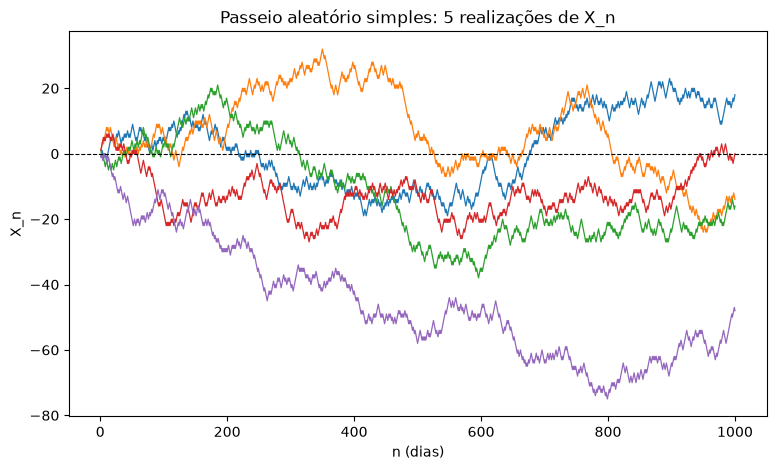

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

n = np.arange(1, n_max + 1)
for _ in range(5):
    Y = rng.choice([-1, 1], size=n_max)
    X = np.cumsum(Y)
    ax.plot(n, X, linewidth=0.9)

ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.set_xlabel('n (dias)')
ax.set_ylabel('X_n')
ax.set_title('Passeio aleatório simples: 5 realizações de X_n')

plt.show()


## Item (b)

**Enunciado:** Calcule $E[X_n]$ e $Var(X_n)$. O fato de $E[X_n] = 0$ significa que $X_n$ deve permanecer próximo de zero quando $n$ é grande? Explique.

**Solução:**

Como os $Y_i$ são iid com $E[Y_i] = 1 \cdot \frac{1}{2} + (-1) \cdot \frac{1}{2} = 0$ e
$Var(Y_i) = E[Y_i^2] - E[Y_i]^2 = 1 - 0 = 1$, e $X_n = \sum_{i=1}^n Y_i$:

$$E[X_n] = \sum_{i=1}^n E[Y_i] = 0,$$

$$Var(X_n) = \sum_{i=1}^n Var(Y_i) = n \quad \text{(soma de variâncias, pois os } Y_i \text{ são independentes)}.$$

$E[X_n] = 0$ **não** significa que $X_n$ fica pertinho de 0 quando $n$ cresce. Isso porque o desvio padrão
de $X_n$ é $\sqrt{Var(X_n)} = \sqrt{n}$, que cresce (ainda que devagar) com $n$ — diferente do caso da
média amostral $\overline{X}_n$ do exercício 10, onde a divisão por $n$ fazia a variância cair
($Var(\overline{X}_n) = 1/n$). Aqui $X_n$ é uma soma, não uma média, então as flutuações típicas de $X_n$
em torno de 0 crescem com $\sqrt{n}$ ao invés de sumir. Abaixo eu confiro isso simulando muitas trajetórias
e comparando a média e a variância empíricas de $X_n$ com a teoria.

In [3]:
valores_n = [10, 100, 1000]

Y_rep = rng.choice([-1, 1], size=(t_max, n_max))
X_rep = np.cumsum(Y_rep, axis=1)

print("n       media empirica   var empirica   var teorica (n)")
for k in valores_n:
    media_emp = X_rep[:, k - 1].mean()
    var_emp = X_rep[:, k - 1].var()
    print(f"{k:5d}   {media_emp:12.3f}   {var_emp:12.3f}   {k:12d}")


n       media empirica   var empirica   var teorica (n)
   10          0.002          9.698             10
  100          0.040         96.188            100
 1000          0.132       1011.543           1000


## Item (c)

**Enunciado:** Seja $K_n$ o número de dias de alta entre os primeiros $n$ dias. Mostre que $X_n = 2K_n - n$ e determine a distribuição de $K_n$. A partir desse resultado, obtenha uma expressão para $\mathbb{P}(X_n = x)$.

**Solução:**

Se $K_n$ é o número de dias de alta (dias com $Y_i = 1$) entre os $n$ primeiros dias, então o número de
dias de queda ($Y_i = -1$) é $n - K_n$. Logo:

$$X_n = \sum_{i=1}^n Y_i = \underbrace{K_n \cdot 1}_{\text{dias de alta}} + \underbrace{(n - K_n)\cdot(-1)}_{\text{dias de queda}} = K_n - n + K_n = 2K_n - n.$$

Como cada dia é independente e tem probabilidade $1/2$ de ser dia de alta, $K_n$ é o número de sucessos em
$n$ ensaios de Bernoulli($1/2$) independentes, ou seja $K_n \sim \text{Binomial}(n, 1/2)$:

$$\mathbb{P}(K_n = k) = \binom{n}{k}\left(\frac{1}{2}\right)^n, \qquad k = 0, 1, \dots, n.$$

Invertendo $x = 2k - n \Rightarrow k = \frac{x+n}{2}$, e substituindo:

$$\mathbb{P}(X_n = x) = \binom{n}{\frac{x+n}{2}}\left(\frac{1}{2}\right)^n,$$

que só faz sentido (é diferente de zero) quando $x + n$ é par e $-n \le x \le n$ (senão $k=(x+n)/2$ não é um
inteiro entre 0 e $n$).

In [4]:
def pmf_Xn(x, n):
    """P(X_n = x), com X_n = 2*K_n - n e K_n ~ Binomial(n, 1/2)."""
    if (x + n) % 2 != 0 or abs(x) > n:
        return 0.0
    k = (x + n) // 2
    return comb(n, k) * (0.5) ** n


# checagem rapida: a soma da pmf sobre todos os x possiveis deve dar 1
n_teste = 20
xs_teste = np.arange(-n_teste, n_teste + 1)
print("soma da PMF (n=20):", sum(pmf_Xn(x, n_teste) for x in xs_teste))


soma da PMF (n=20): 1.0


## Item (d)

**Enunciado:** Repita a simulação muitas vezes e construa histogramas de $X_n$ para $n = 10, 100$ e $1000$. Compare-os com a distribuição teórica obtida no item anterior. Calcule também o desvio-padrão de $X_n$ para cada valor de $n$ e use esse resultado para descrever como a largura típica das flutuações depende de $n$.

**Solução:**

Uso as mesmas `t_max` trajetórias simuladas no item (b) e comparo o histograma de $X_n$ em cada $n$ com a
PMF teórica $\mathbb{P}(X_n = x)$ calculada acima. Também comparo o desvio-padrão empírico com $\sqrt{n}$.

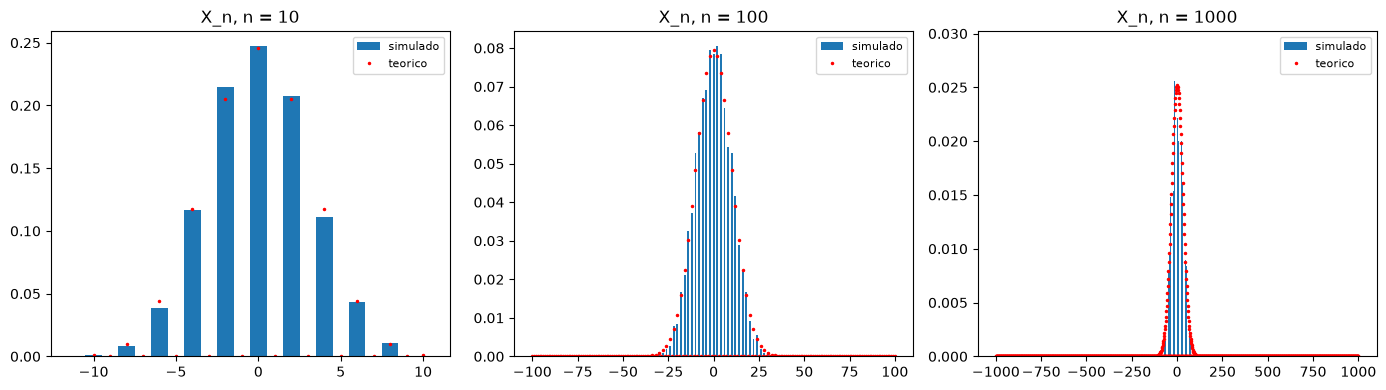

Desvio-padrao de X_n: empirico vs. teorico (sqrt(n))
n =    10   empirico = 3.114   teorico = 3.162
n =   100   empirico = 9.808   teorico = 10.000
n =  1000   empirico = 31.805   teorico = 31.623


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

for j, k in enumerate(valores_n):
    dados = X_rep[:, k - 1]

    bins = np.arange(dados.min() - 1, dados.max() + 2) - 0.5
    ax[j].hist(dados, bins=bins, density=True, label='simulado')

    xs = np.arange(-k, k + 1)
    pmf = np.array([pmf_Xn(x, k) for x in xs])
    ax[j].plot(xs, pmf, 'r.', markersize=3, label='teorico')

    ax[j].set_title(f'X_n, n = {k}')
    ax[j].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Desvio-padrao de X_n: empirico vs. teorico (sqrt(n))")
for k in valores_n:
    dp_emp = X_rep[:, k - 1].std()
    dp_teo = np.sqrt(k)
    print(f"n = {k:5d}   empirico = {dp_emp:.3f}   teorico = {dp_teo:.3f}")


## Conclusão

- As trajetórias simuladas em (a) mostram um comportamento tipicamente errático, sem convergir para nenhum
  valor fixo — o passeio se afasta da origem conforme $n$ cresce.
- Em (b), $E[X_n] = 0$ para todo $n$, mas isso não implica que $X_n$ fica perto de zero: como $Var(X_n) = n$
  cresce sem limite, as flutuações típicas de $X_n$ (medidas pelo desvio padrão $\sqrt{n}$) também crescem
  com $n$, só que mais devagar que o próprio $n$.
- Em (c), escrever $X_n = 2K_n - n$ com $K_n \sim \text{Binomial}(n, 1/2)$ dá a distribuição exata de $X_n$
  para qualquer $n$, não só assintoticamente.
- Em (d), os histogramas simulados batem bem com a PMF teórica pra todos os $n$ testados, e o desvio-padrão
  empírico fica bem próximo de $\sqrt{n}$ em cada caso — confirmando que a largura típica das flutuações de
  $X_n$ cresce como $\sqrt{n}$, e não fica limitada nem vai a zero.